In [1]:
import numpy as np   
import pandas as pd   
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.neighbors import KNeighborsRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVR
from xgboost import XGBRegressor
import lightgbm as lgb
from catboost import CatBoostRegressor

In [3]:
df=pd.read_csv("lalpurja_dataset_ready_after_feature_engineering.csv")

In [4]:
df_ml_lp=df.copy()

In [6]:
# ─────────────────────────────────────────
# STEP 1 — DEFINE X AND Y
# Drop price_per_aana from features — it's our target
# Apply log1p to target — normalizes right skewed prices
# All values positive (min 600k) so log1p is safe here
# ─────────────────────────────────────────
X = df_ml_lp.drop(columns=['price_per_aana'])
y = np.log1p(df_ml_lp['price_per_aana'])

print(f"Features: {X.shape[1]}")
print(f"Samples:  {X.shape[0]}")
print(f"Target min: {y.min():.4f}, max: {y.max():.4f}")

Features: 29
Samples:  1214
Target min: 13.3047, max: 16.1080


In [7]:
# ─────────────────────────────────────────
# STEP 2 — TRAIN TEST SPLIT
# 80/20 split — consistent with housing and df_land models
# random_state=42 ensures same split every run
# ─────────────────────────────────────────
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)
print(f"\nTraining samples: {X_train.shape[0]}")
print(f"Testing samples:  {X_test.shape[0]}")


Training samples: 971
Testing samples:  243


In [8]:
# ─────────────────────────────────────────
# STEP 3 — SCALE FOR LINEAR MODELS AND SVR
# Tree models don't need scaling — they use splits
# Linear models and SVR need features on same scale
# StandardScaler: mean=0, std=1 for each feature
# ─────────────────────────────────────────
scaler     = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc  = scaler.transform(X_test)

In [9]:
# ─────────────────────────────────────────
# STEP 4 — TRAIN ALL MODELS
# ─────────────────────────────────────────
models = {
    'Linear Regression': LinearRegression(),
    'Ridge':             Ridge(alpha=1.0),
    'Lasso':             Lasso(alpha=0.001),
    'Random Forest':     RandomForestRegressor(n_estimators=100, random_state=42),
    'Gradient Boosting': GradientBoostingRegressor(n_estimators=100, random_state=42),
    'XGBoost':           XGBRegressor(n_estimators=100, random_state=42, verbosity=0),
    'LightGBM':          lgb.LGBMRegressor(n_estimators=100, random_state=42, verbose=-1),
    'CatBoost':          CatBoostRegressor(n_estimators=100, random_state=42, verbose=0),
    'KNN':               KNeighborsRegressor(n_neighbors=5),
    'SVR':               SVR(kernel='rbf')
}

# Linear models need scaled data, tree models don't
linear_models = ['Linear Regression', 'Ridge', 'Lasso', 'KNN', 'SVR']
results = []

for name, model in models.items():
    if name in linear_models:
        model.fit(X_train_sc, y_train)
        y_pred = model.predict(X_test_sc)
    else:
        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)

    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    mae  = mean_absolute_error(y_test, y_pred)
    r2   = r2_score(y_test, y_pred)

    results.append({
        'Model':      name,
        'RMSE (log)': round(rmse, 4),
        'MAE (log)':  round(mae, 4),
        'R² Score':   round(r2, 4),
        'Error %':    f"{(np.exp(mae) - 1) * 100:.1f}%"
    })
    print(f"✅ {name} done — R²: {r2:.4f}")


✅ Linear Regression done — R²: 0.7302
✅ Ridge done — R²: 0.7293
✅ Lasso done — R²: 0.7282
✅ Random Forest done — R²: 0.7274
✅ Gradient Boosting done — R²: 0.7244
✅ XGBoost done — R²: 0.7233
✅ LightGBM done — R²: 0.7006
✅ CatBoost done — R²: 0.7134
✅ KNN done — R²: 0.6673
✅ SVR done — R²: 0.6628


In [10]:
# ─────────────────────────────────────────
# STEP 5 — COMPARE RESULTS
# ─────────────────────────────────────────
results_df = pd.DataFrame(results).sort_values('R² Score', ascending=False)
print("\n=== Model Comparison ===")
print(results_df.to_string(index=False))


=== Model Comparison ===
            Model  RMSE (log)  MAE (log)  R² Score Error %
Linear Regression      0.2440     0.1804    0.7302   19.8%
            Ridge      0.2444     0.1806    0.7293   19.8%
            Lasso      0.2449     0.1812    0.7282   19.9%
    Random Forest      0.2453     0.1797    0.7274   19.7%
Gradient Boosting      0.2466     0.1789    0.7244   19.6%
          XGBoost      0.2471     0.1822    0.7233   20.0%
         CatBoost      0.2515     0.1843    0.7134   20.2%
         LightGBM      0.2570     0.1859    0.7006   20.4%
              KNN      0.2710     0.2019    0.6673   22.4%
              SVR      0.2728     0.2007    0.6628   22.2%


In [11]:
from sklearn.model_selection import RandomizedSearchCV

param_grids = {
    'Linear Regression': {
        'model': Ridge(),  # Ridge is better than pure Linear for tuning
        'params': {
            'alpha': [0.001, 0.01, 0.1, 1.0, 5.0, 10.0, 50.0, 100.0]
        }
    },
    'Random Forest': {
        'model': RandomForestRegressor(random_state=42),
        'params': {
            'n_estimators':  [100, 200, 300, 500],
            'max_depth':     [5, 10, 15, None],
            'min_samples_split': [2, 5, 10],
            'max_features':  ['sqrt', 'log2', 0.5]
        }
    },
    'Gradient Boosting': {
        'model': GradientBoostingRegressor(random_state=42),
        'params': {
            'n_estimators':  [100, 200, 300],
            'learning_rate': [0.01, 0.05, 0.1],
            'max_depth':     [3, 5, 7],
            'subsample':     [0.7, 0.8, 1.0]
        }
    },
    'XGBoost': {
        'model': XGBRegressor(random_state=42, verbosity=0),
        'params': {
            'n_estimators':     [200, 300, 500],
            'learning_rate':    [0.01, 0.05, 0.1],
            'max_depth':        [3, 5, 7],
            'subsample':        [0.7, 0.8, 1.0],
            'colsample_bytree': [0.7, 0.8, 1.0],
            'gamma':            [0, 0.1, 0.2]
        }
    },
    'CatBoost': {
        'model': CatBoostRegressor(random_state=42, verbose=0),
        'params': {
            'iterations':    [500, 1000, 1500],
            'learning_rate': [0.01, 0.05, 0.1],
            'depth':         [4, 6, 8],
            'l2_leaf_reg':   [1, 3, 5, 9]
        }
    }
}

tuned_models  = {}
tuned_results = []

for name, config in param_grids.items():
    print(f"🔍 Tuning {name}...")

    n_iter = 20 if name == 'Linear Regression' else 50

    search = RandomizedSearchCV(
        estimator=config['model'],
        param_distributions=config['params'],
        n_iter=n_iter, cv=5, scoring='r2',
        random_state=42, n_jobs=-1
    )

    if name == 'Linear Regression':
        search.fit(X_train_sc, y_train)
        tuned_models[name] = search.best_estimator_
        y_pred = tuned_models[name].predict(X_test_sc)
    else:
        search.fit(X_train, y_train)
        tuned_models[name] = search.best_estimator_
        y_pred = tuned_models[name].predict(X_test)

    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    mae  = mean_absolute_error(y_test, y_pred)
    r2   = r2_score(y_test, y_pred)

    tuned_results.append({
        'Model':       name,
        'RMSE (log)':  round(rmse, 4),
        'MAE (log)':   round(mae, 4),
        'R² Score':    round(r2, 4),
        'Error %':     f"{(np.exp(mae) - 1) * 100:.1f}%",
        'Best Params': search.best_params_
    })
    print(f"✅ {name} done — R²: {r2:.4f}")
print('HpyerParameterTuning Done. ✅')

🔍 Tuning Linear Regression...


C:\Users\DELL\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sklearn\model_selection\_search.py:320: UserWarning: The total space of parameters 8 is smaller than n_iter=20. Running 8 iterations. For exhaustive searches, use GridSearchCV.
  warnings.warn(


✅ Linear Regression done — R²: 0.7294
🔍 Tuning Random Forest...
✅ Random Forest done — R²: 0.7251
🔍 Tuning Gradient Boosting...
✅ Gradient Boosting done — R²: 0.7361
🔍 Tuning XGBoost...
✅ XGBoost done — R²: 0.7369
🔍 Tuning CatBoost...
✅ CatBoost done — R²: 0.7444
HpyerParameterTuning Done. ✅


In [12]:
print("\n=== Best Parameters ===")
for result in tuned_results:
    print(f"\n{result['Model']}:")
    for param, value in result['Best Params'].items():
        print(f"  {param}: {value}")


=== Best Parameters ===

Linear Regression:
  alpha: 10.0

Random Forest:
  n_estimators: 100
  min_samples_split: 5
  max_features: 0.5
  max_depth: 15

Gradient Boosting:
  subsample: 0.7
  n_estimators: 100
  max_depth: 7
  learning_rate: 0.05

XGBoost:
  subsample: 0.7
  n_estimators: 500
  max_depth: 7
  learning_rate: 0.05
  gamma: 0.1
  colsample_bytree: 0.8

CatBoost:
  learning_rate: 0.01
  l2_leaf_reg: 5
  iterations: 1500
  depth: 4


In [13]:
tuned_df = pd.DataFrame(tuned_results).sort_values('R² Score', ascending=False)
print("\n=== Tuned Model Comparison ===")
print(tuned_df[['Model','RMSE (log)','MAE (log)','R² Score','Error %']].to_string(index=False))


=== Tuned Model Comparison ===
            Model  RMSE (log)  MAE (log)  R² Score Error %
         CatBoost      0.2375     0.1747    0.7444   19.1%
          XGBoost      0.2410     0.1785    0.7369   19.5%
Gradient Boosting      0.2414     0.1783    0.7361   19.5%
Linear Regression      0.2444     0.1805    0.7294   19.8%
    Random Forest      0.2463     0.1800    0.7251   19.7%


=== Feature Importance — CatBoost ===
                Feature  Importance
   neighborhood_encoded   55.009141
   municipality_encoded    5.372642
              road_type    4.208722
          bhatbhateni_m    3.195024
              airport_m    3.132301
       urban_centrality    2.239091
   amenity_access_score    2.209447
        road_width_feet    2.112142
    road_access_quality    2.030527
               log_land    1.991203
neighborhood_x_district    1.895389
       plot_value_score    1.856831
         land_size_aana    1.815082
  commercial_zone_score    1.667430
             hospital_m    1.514973
      facing_road_width    1.392773
       police_station_m    1.276169
     public_transport_m    1.128887
      comm_road_premium    1.082422
             pharmacy_m    1.046814
    ring_road_proximity    0.884097
               district    0.840687
            ring_road_m    0.583572
    municipality_x_ward    0.571745
               school_m    0.334974
          property_face   

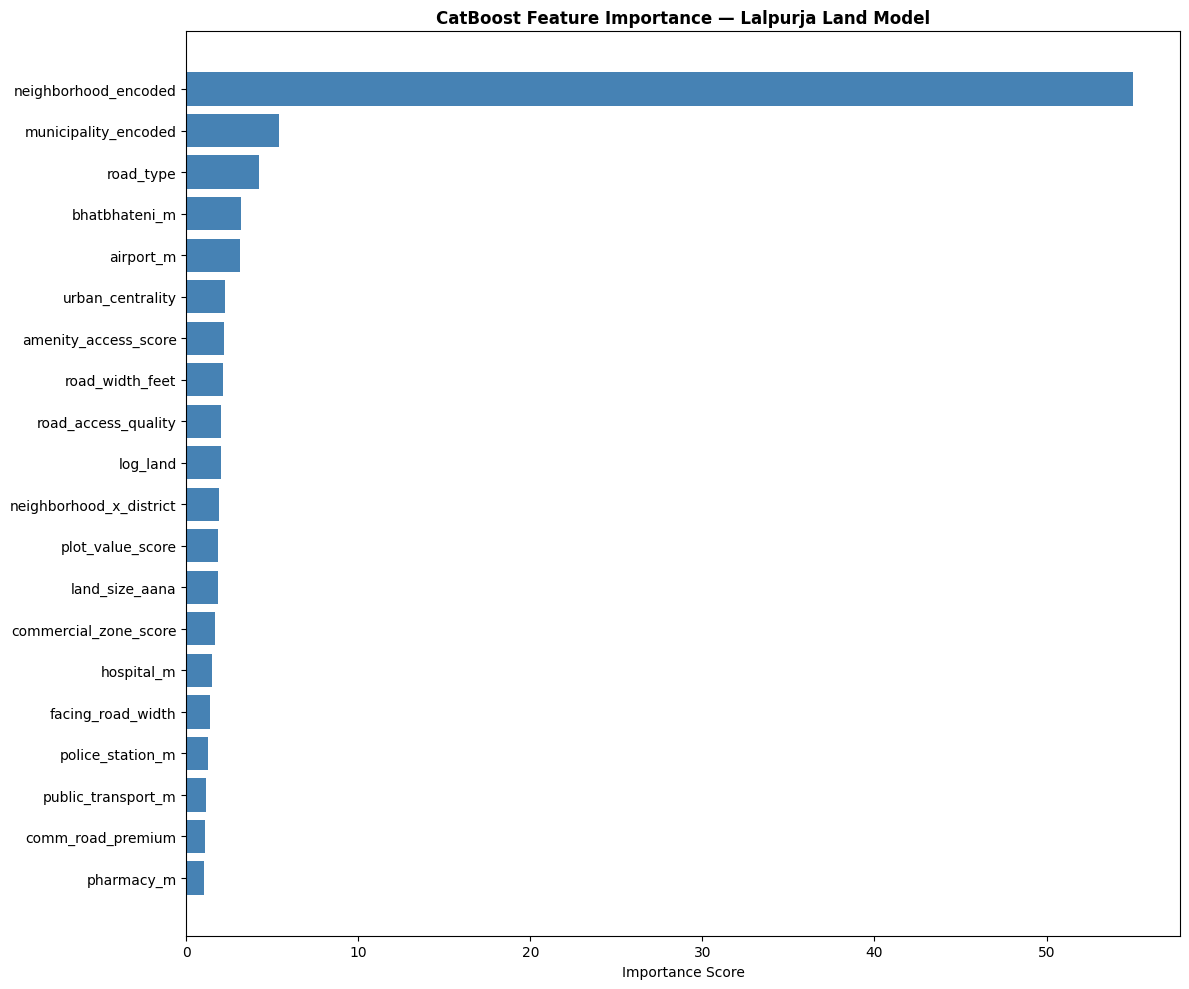

In [14]:
import matplotlib.pyplot as plt

# ─────────────────────────────────────────
# FEATURE IMPORTANCE — CATBOOST
# Why: Tells us which features the model relies on most
# Helps validate our feature engineering decisions
# and identify any potential leakage
# ─────────────────────────────────────────
best_model = tuned_models['CatBoost']

# Get feature importances
feature_names  = X.columns.tolist()
importances    = best_model.get_feature_importance()
importance_df  = pd.DataFrame({
    'Feature':    feature_names,
    'Importance': importances
}).sort_values('Importance', ascending=False)

print("=== Feature Importance — CatBoost ===")
print(importance_df.to_string(index=False))

# Plot
plt.figure(figsize=(12, 10))
plt.barh(importance_df['Feature'][:20],
         importance_df['Importance'][:20], color='steelblue')
plt.title('CatBoost Feature Importance — Lalpurja Land Model', fontweight='bold')
plt.xlabel('Importance Score')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

In [15]:
# Quick sanity check — if neighborhood_encoded is legitimate
# then removing it should drop R² significantly but not to zero
from sklearn.metrics import r2_score

# Test without neighborhood_encoded
X_no_neighborhood = X_test.drop(columns=['neighborhood_encoded'])
X_train_no_neighborhood = X_train.drop(columns=['neighborhood_encoded'])

# Retrain CatBoost without neighborhood
test_model = CatBoostRegressor(
    iterations=1500, learning_rate=0.01,
    depth=4, l2_leaf_reg=5,
    random_state=42, verbose=0
)
test_model.fit(X_train_no_neighborhood, y_train)
y_pred_no_n = test_model.predict(X_no_neighborhood)
r2_no_n = r2_score(y_test, y_pred_no_n)

print(f"R² with neighborhood_encoded:    0.7444")
print(f"R² without neighborhood_encoded: {r2_no_n:.4f}")
print(f"Drop in R²: {0.7444 - r2_no_n:.4f}")

R² with neighborhood_encoded:    0.7444
R² without neighborhood_encoded: 0.7173
Drop in R²: 0.0271


In [16]:
import joblib


In [17]:
# ─────────────────────────────────────────
# SAVE FINAL LALPURJA MODEL
# Best model: CatBoost R² 0.7444, Error 19.1%
# ─────────────────────────────────────────
joblib.dump(tuned_models['CatBoost'], 'catboost_lalpurja_model_final.pkl')


['catboost_lalpurja_model_final.pkl']

In [18]:
# Verify by loading and predicting
loaded_model = joblib.load('catboost_lalpurja_model_final.pkl')
sample_preds = np.expm1(loaded_model.predict(X_test[:3]))
print(f"✅ Lalpurja model saved")
print(f"✅ Sample predictions (price per aana): {sample_preds.astype(int)}")

✅ Lalpurja model saved
✅ Sample predictions (price per aana): [3300916 2635172 3794663]


In [19]:
# ─────────────────────────────────────────
# FINAL MODEL SUMMARY
# ─────────────────────────────────────────
print(f"\n=== Lalpurja Model Summary ===")
print(f"Algorithm:    CatBoost")
print(f"R² Score:     0.7444")
print(f"Average Error: 19.1%")
print(f"Training rows: {X_train.shape[0]}")
print(f"Testing rows:  {X_test.shape[0]}")
print(f"Features:      {X.shape[1]}")


=== Lalpurja Model Summary ===
Algorithm:    CatBoost
R² Score:     0.7444
Average Error: 19.1%
Training rows: 971
Testing rows:  243
Features:      29
